![lop](../../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    FN2O vs. USTAR
</b>
</span>

---
**Notebook version**: `1` (19 Nov 2023)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# Background
- This notebook investigates the eddy covariance CH4 flux (nmol m-2 s-1) in relation to USTAR (m s-1).
- The used dataset is a special version of the [FLUXNET-CH4 Community Product](https://fluxnet.org/data/fluxnet-ch4-community-product/).
- `FCH4` in this notebook is the flux **before** USTAR filtering.

# Setup

In [16]:
# Variable names in data files
USTAR1 = 'USTAR'
FLUX1 = 'FN2O_L3.1_L3.2_QCF0'  # Highest-quality N2O fluxes after outlier removal

# Source folder with data files in parquet format
SOURCEDIR = r"data/N2O"

# Imports

In [17]:
import importlib.metadata
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd

from diive.core.io.filereader import search_files
from diive.core.io.files import load_parquet
from diive.core.plotting.scatter import ScatterXY

version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.70.1


# Search data files
- All data files were first converted to the [Parquet](https://parquet.apache.org/) format for faster processing.

In [18]:
foundfiles = search_files(searchdirs=[SOURCEDIR], pattern='*.parquet')
# foundfiles = foundfiles[0:11]
[print(f"{ix}: {f}") for ix, f in enumerate(foundfiles)];

0: data\N2O\CH-CHA_2022_FN2O_Level3.2.parquet


# Determine required number of rows for large figure

In [19]:
n_files = len(foundfiles)
plots_per_row = 1

# Plotting function (with bins)

In [21]:
def plot(foundfiles: list, patchid: int):
    fig = plt.figure(facecolor='white', figsize=(28.8, 21.6), dpi=72)
    gs = gridspec.GridSpec(3, 4)  # rows, cols   
    gs.update(wspace=0.15, hspace=0.25, left=0.03, right=0.97, top=0.97, bottom=0.03)
    
    current_row = 0
    col = 0
    axes = {} 
    for ix, ff in enumerate(foundfiles):
        site = ff.name.replace('AMF_', '').split('_')[0]
        df = load_parquet(ff)
       
        if col > plots_per_row-1:    
            col = 0
            current_row += 1        
        ax = fig.add_subplot(gs[current_row, col])        
        xcol = USTAR1 if USTAR1 in df.columns else USTAR2
        ycol = FLUX1 if FLUX1 in df.columns else FLUX2    
        ScatterXY(x=df[xcol], y=df[ycol], nbins=20, title=site, binagg='median', ax=ax, ylim='auto').plot()        
        col += 1   
    fig.savefig(f"FN2OvsUSTAR_{patchid}.png")

In [22]:
load_parquet(foundfiles)

Loaded .parquet file [WindowsPath('data/N2O/CH-CHA_2022_FN2O_Level3.2.parquet')] (0.066 seconds). Detected time resolution of <30 * Minutes> / 30T 


,AIR_MV,AIR_DENSITY,AIR_RHO_CP,AIR_CP,AOA_METHOD,AXES_ROTATION_METHOD,BOWEN,BURBA_METHOD,BADM_LOCATION_LAT,BADM_LOCATION_LONG,BADM_LOCATION_ELEV,BADM_HEIGHTC,BADM_INST_SAMPLING_INT,BADM_INST_AVERAGING_INT,BADM_INST_MODEL_SA,...,FN2O_L3.1,FN2O_L3.1_QCF,FN2O_L3.1_QCF0,FLAG_L3.2_FN2O_L3.1_QCF_OUTLIER_ABSLIM_TEST,FLAG_L3.2_FN2O_L3.1_QCF_OUTLIER_ZSCORE_TEST,FLAG_L3.2_FN2O_L3.1_QCF_OUTLIER_LOFDTNT_TEST,FLAG_L3.2_FN2O_L3.1_QCF_OUTLIER_LOCALSD_TEST,FLAG_L3.2_FN2O_L3.1_QCF_OUTLIER_LOCALSD_2_TEST,FLAG_L3.2_FN2O_L3.1_QCF_OUTLIER_ABSLIM_DTNT_TEST,SUM_L3.2_FN2O_L3.1_HARDFLAGS,SUM_L3.2_FN2O_L3.1_SOFTFLAGS,SUM_L3.2_FN2O_L3.1_FLAGS,FLAG_L3.2_FN2O_L3.1_QCF,FN2O_L3.1_L3.2_QCF,FN2O_L3.1_L3.2_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-12-31 19:15:00,0.023947,1.20908,1219.53,1008.64,0.0,1.0,-8.078410,0.0,47.2102,8.41044,393.0,0.500000,20.0,30.0,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,2.0,NaN,NaN
2021-12-31 19:45:00,0.023871,1.21295,1223.29,1008.52,0.0,1.0,12.796600,0.0,47.2102,8.41044,393.0,0.500000,20.0,30.0,NaN,...,0.881074,0.881074,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,0.881074,NaN
2021-12-31 20:15:00,0.023850,1.21400,1224.43,1008.59,0.0,1.0,0.670319,0.0,47.2102,8.41044,393.0,0.500000,20.0,30.0,NaN,...,0.141011,0.141011,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,0.141011,NaN
2021-12-31 20:45:00,0.023850,1.21399,1224.49,1008.65,0.0,1.0,9.032780,0.0,47.2102,8.41044,393.0,0.500000,20.0,30.0,NaN,...,0.586059,0.586059,0.586059,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.586059,0.586059
2021-12-31 21:15:00,0.023788,1.21717,1227.41,1008.41,0.0,1.0,1.027930,0.0,47.2102,8.41044,393.0,0.500000,20.0,30.0,NaN,...,0.106046,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,2.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-07-11 13:45:00,0.025400,1.13436,1149.37,1013.23,0.0,1.0,NaN,0.0,47.2102,8.41044,393.0,0.141489,20.0,30.0,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,6.0,2.0,NaN,NaN
2022-07-11 14:15:00,0.025430,1.13292,1148.04,1013.35,0.0,1.0,NaN,0.0,47.2102,8.41044,393.0,0.141489,20.0,30.0,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,6.0,2.0,NaN,NaN
2022-07-11 14:45:00,0.025453,1.13180,1147.09,1013.51,0.0,1.0,NaN,0.0,47.2102,8.41044,393.0,0.141489,20.0,30.0,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,6.0,2.0,NaN,NaN


# Create plots (with bins)

Patch 1 (0-12)
Loaded .parquet file data\N2O\CH-CHA_2022_FN2O_Level3.2.parquet (0.051 seconds). Detected time resolution of <30 * Minutes> / 30T 


F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\core\plotting\scatter.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.xy_df_binned = self.xy_df.groupby(groupcol).agg({'mean', 'median', 'std', 'count', q25, q75})


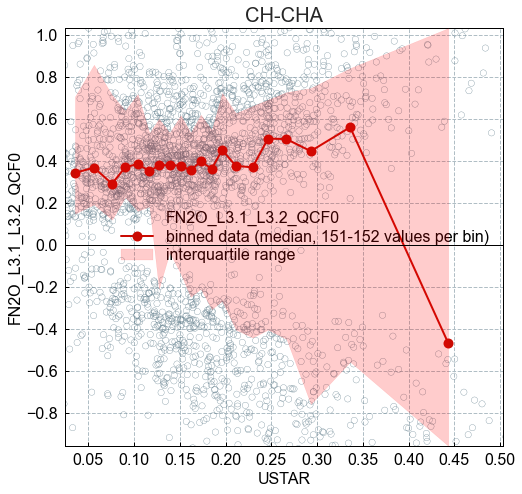

In [23]:
patch = 0
for firstfile in range(0, n_files, 12):    
    patch += 1
    lastfile = firstfile + 12
    print(f"Patch {patch} ({firstfile}-{lastfile})")
    plot(foundfiles=foundfiles[firstfile:lastfile], patchid=patch)    